# STEP 2 · 轨迹 → 荷电状态(SoC) → 低电量需求

**目的**：把 GPS 几何换算成耗电与 SoC，定义“低电量事件”，对初始电量分布做蒙特卡洛集成，得到**期望需求面**。

**Example**：全员满电(naive)得 ~1,330 事件 / ~875 需求块；改用现实初始电量分布后需求约 **2.3×**(~3,100 事件 / ~1,400 块)，且空间格局稳定。

In [47]:
import os, sys, time, importlib
sys.path.insert(0, os.getcwd())          # STEP_0 已在本目录生成 cso_config.py / cso_engine.py
# 数据默认在“本 Code 目录的上一级”(项目根, 含 parquet 与 station csv)。如不同请改下一行或设环境变量 CSO_DATA：
# os.environ['CSO_DATA'] = r'D:/Desktop/香港大学/20260521 根据网约车轨迹优化充电站'
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'font.sans-serif': ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS', 'DejaVu Sans'],
    'axes.unicode_minus': False,
})
import cso_config as C, cso_engine as E
importlib.reload(C); importlib.reload(E)
print('当前城市:', C.city()['label'], '| 数据:', C.city()['raw_path'].name, '| 缓存:', C.CACHE)

当前城市: 广州 Guangzhou | 数据: Taxi_2019_10_14_admin_4401.parquet | 缓存: D:\Desktop\香港大学\20260521 根据网约车轨迹优化充电站\Code\_cache


In [48]:
if not C.cache_file('segments').exists() or not C.cache_file('stations').exists():
    print('首次运行：预计算分段缓存 ...'); print(E.precompute_segments())
else:
    print('分段缓存已存在，直接载入。')
z = E.load_segments(); vc,lon,lat = z['vc'],z['lon'],z['lat']
d,dt,v,start = z['d'],z['dt'],z['v'],z['start']; n_veh = int(z['n_veh'])
print('GPS 记录 %d | 车辆 %d' % (len(vc), n_veh))

分段缓存已存在，直接载入。
GPS 记录 13196639 | 车辆 33406


## 2.1 累计耗电与 SoC 轨迹
按车型能耗模型累计耗电，还原某辆车的 SoC 锯齿曲线(每次触底=一个补能周期)。

车型 model3, 电池 78.4 kWh | 单车累计耗电中位 12.4 kWh (~83 km)
Vehicle #10865: 131 records
Vehicle #24372: 246 records
Vehicle #14995: 429 records
Vehicle #5204: 873 records


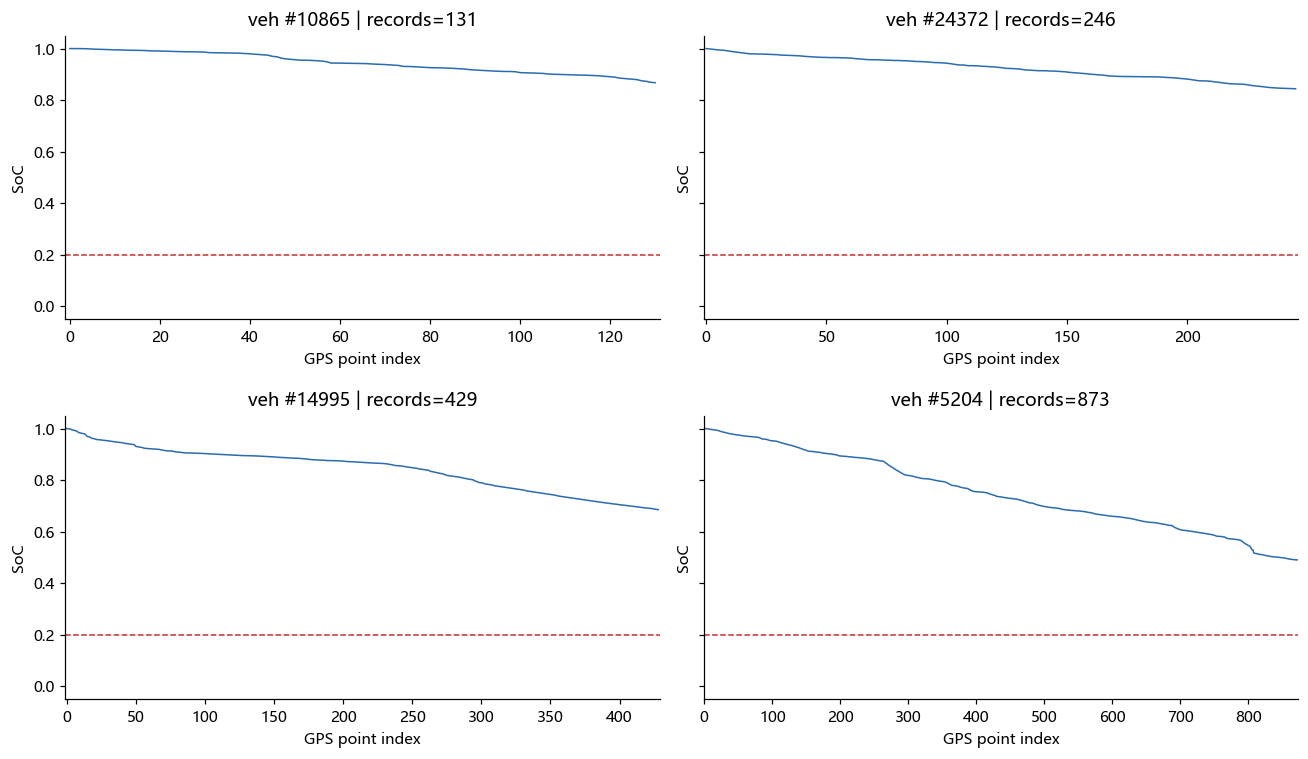

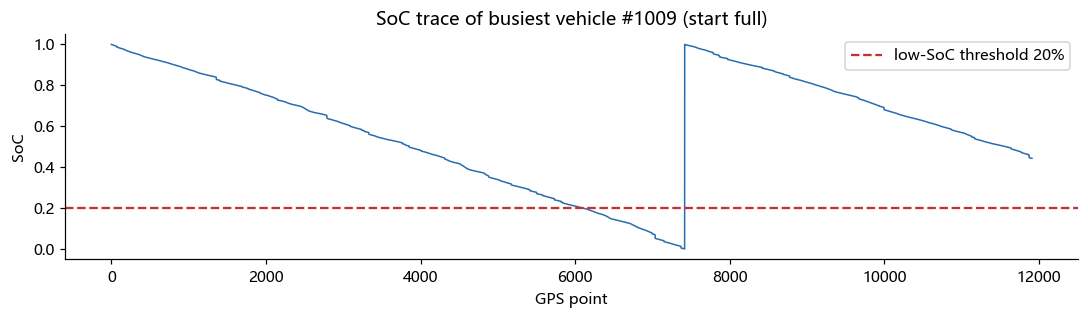

Vehicle #1009: 11912 records


In [49]:
batt = C.VEHICLES[C.VEH_DEFAULT]['batt']
cum = E.cumulative_kwh(d, dt, v, vc, start, C.VEH_DEFAULT)
print('车型 %s, 电池 %.1f kWh | 单车累计耗电中位 %.1f kWh (~%.0f km)' % (C.VEH_DEFAULT, batt, np.median(cum[~start]), np.median(cum[~start])/0.15))

# 分批选取对应百分比为20%、40%、60%、80%记录数的车辆，然后在一张图上画出 SoC 轨迹（2*2）。
counts = np.bincount(vc, minlength=n_veh)
veh_pool = np.flatnonzero(counts > 0)
veh_sorted = veh_pool[np.argsort(counts[veh_pool])]

ps = [0.3, 0.5, 0.7, 0.9]
veh_show = [int(veh_sorted[min(int(round((len(veh_sorted) - 1) * p)), len(veh_sorted) - 1)]) for p in ps]
idx_show = [np.where(vc == veh)[0] for veh in veh_show] # 每辆车的 GPS 记录索引

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False, sharey=True)
axes = axes.ravel()

for ax, veh, idx in zip(axes, veh_show, idx_show):
    ce_v = cum[idx]
    soc_v = 1 - (ce_v % batt) / batt
    ax.plot(soc_v, lw=1, color='#2b6cb0')
    ax.axhline(C.SOC_LOW, ls='--', color='#c53030', lw=1)
    ax.set_title('veh #%d | records=%d' % (veh, len(idx)))
    ax.set_xlabel('GPS point index')
    ax.set_ylabel('SoC')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(left=-1, right=len(soc_v))
    
    print('Vehicle #%d: %d records' % (veh, len(idx)))

plt.tight_layout(h_pad=1.5)
plt.show()
veh0 = int(np.argsort(np.bincount(vc))[-2])
idx0 = np.where(vc==veh0)[0]; ce = cum[idx0]
soc = 1 - (ce - np.floor(ce/batt)*batt)/batt
plt.figure(figsize=(10,3)); plt.plot(soc, lw=1, color='#2b6cb0')
plt.axhline(C.SOC_LOW, ls='--', color='#c53030', label='low-SoC threshold %.0f%%'%(100*C.SOC_LOW))
plt.title('SoC trace of busiest vehicle #%d (start full)'%veh0); plt.xlabel('GPS point'); plt.ylabel('SoC'); plt.legend(); plt.tight_layout(); plt.show()
print ('Vehicle #%d: %d records' % (veh0, len(idx0)))

## 2.2 naive 需求全员满电
每个放电周期首个跌破阈值的点 = 一次低电量事件，按 1km 栅格聚合。

naive 事件数 = 1331 | 需求块 |D| = 874


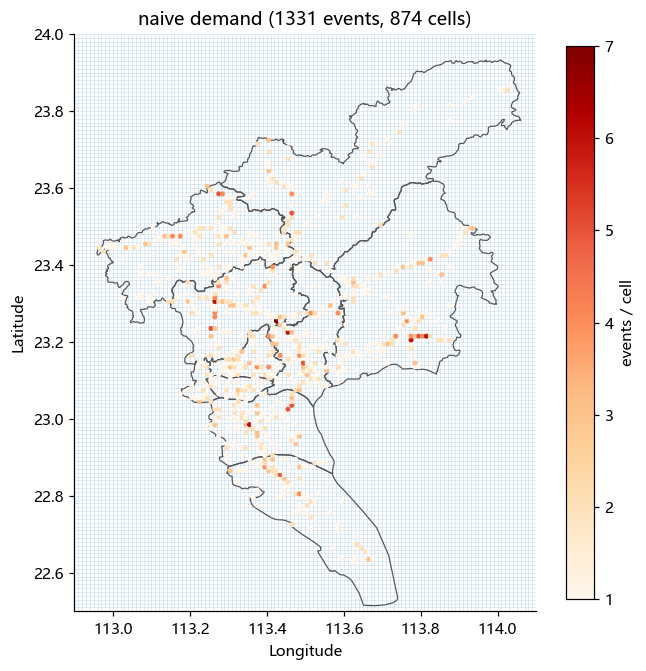

In [50]:
D_naive = E.naive_demand_surface()
ub_n, w_n, lc_n, ac_n = D_naive['master'], D_naive['w_naive'], D_naive['lon_c'], D_naive['lat_c']
print('naive 事件数 = %d | 需求块 |D| = %d' % (D_naive['n_ev'], D_naive['nD']))

fig, ax = plt.subplots(figsize=(6.2,6.2))
E.draw_city_context(ax=ax, show_admin=True, show_grid=True, grid_alpha=0.25, grid_linewidth=0.35)

s = ax.scatter(lc_n, ac_n, c=w_n, cmap='OrRd', s=5, zorder=4)
plt.colorbar(s, ax=ax, label='events / cell', fraction=0.046)
ax.set_title('naive demand (%d events, %d cells)'%(D_naive['n_ev'], D_naive['nD']))
plt.tight_layout(); plt.show()


## 2.3 蒙特卡洛初始 SoC 抽样与需求块稳定性
`E.monte_carlo_demand_surface` 只做初始 SoC 的 DRAWS 次抽样集成，输出 `w_exp` 和**出现频率**。需要和 naive 对比时，再用 `E.align_demand_surfaces` 对齐栅格。

In [51]:
DRAWS = C.N_ENSEMBLE # 蒙特卡洛抽样次数
t0 = time.time()
D_mc = E.monte_carlo_demand_surface(draws=DRAWS)
D = E.align_demand_surfaces(D_mc, D_naive)
print('集成 %d 次, 用时 %.1fs' % (DRAWS, time.time()-t0))
print('每次抽样: 事件 %.0f ± %.0f | 需求块 %.0f ± %.0f | 主网格 %d 格' % (D['n_ev'].mean(), D['n_ev'].std(), D['nD'].mean(), D['nD'].std(), len(D['master'])))
print('相对 naive(%d 事件)：现实初始电量使需求约 %.1f×' % (D_naive['n_ev'], D['n_ev'].mean()/D_naive['n_ev']))


集成 100 次, 用时 29.5s
每次抽样: 事件 3109 ± 26 | 需求块 1410 ± 16 | 主网格 3327 格
相对 naive(1331 事件)：现实初始电量使需求约 2.3×


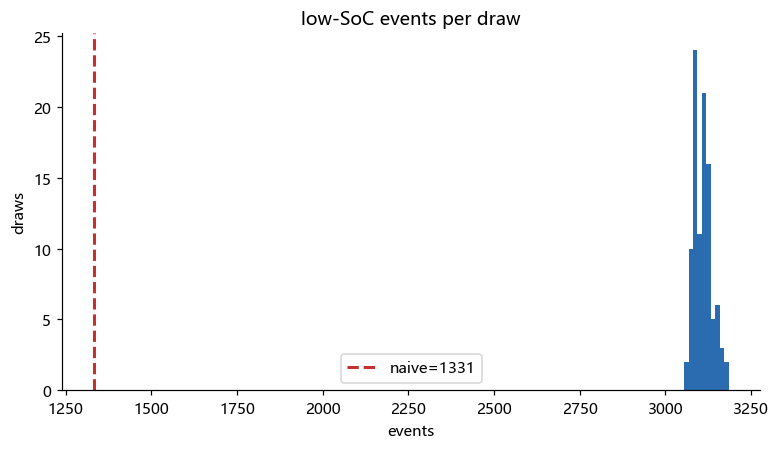

In [52]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.hist(D['n_ev'], bins=10, color='#2b6cb0')
ax.axvline(D_naive['n_ev'], ls='--', lw=2, color='#c53030', label='naive=%d' % D_naive['n_ev'])
ax.set_title('low-SoC events per draw')
ax.set_xlabel('events')
ax.set_ylabel('draws')
ax.legend()
plt.tight_layout(); plt.show()


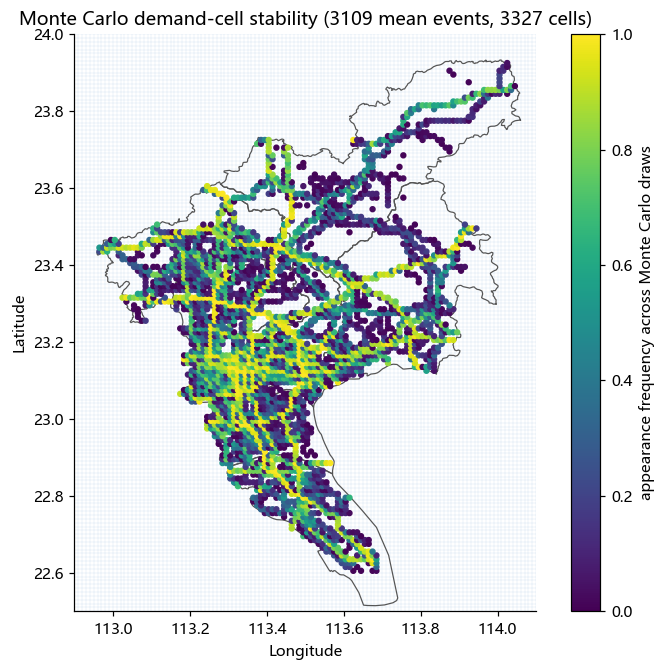

In [58]:
fig, ax = plt.subplots(figsize=(7.2, 6.2))
E.draw_city_context(ax=ax, show_admin=True, show_grid=True, grid_alpha=0.20, grid_linewidth=0.25)
m = D_mc['w_exp'] > 0
s2 = ax.scatter(D_mc['lon_c'][m], D_mc['lat_c'][m], c=D_mc['appear'][m], cmap='viridis', s=10, vmin=0, vmax=1, zorder=4)
plt.colorbar(s2, ax=ax, label='appearance frequency across Monte Carlo draws', fraction=0.046)
ax.set_title('Monte Carlo demand-cell stability (%d mean events, %d cells)' % (round(D_mc['n_ev'].mean()), len(D_mc['master'])))
plt.tight_layout(); plt.show()